This notebook serves for me to understand how a foundational unet works experiment with the unet model. References:
1. [https://www.kaggle.com/code/awsaf49/uwmgi-unet-train-pytorch](URL)
2. [https://www.kaggle.com/code/ammarnassanalhajali/uwmgi-unet-pytorch-train-with-eda](URL)


In [1]:
import numpy as np 
import pandas as pd 
import random
from glob import glob
import os 
import shutil 
from tqdm import tqdm 
tqdm.pandas()
import copy 
import joblib 
from collections import defaultdict
import gc 
import matplotlib.pyplot as plt 
from matplotlib.patches import Rectangle

In [2]:
import cv2 
from sklearn.model_selection import (StratifiedKFold,
                                     KFold,
                                     StratifiedGroupKFold)
import torch 
from torch import nn 
from torch.utils.data import Dataset,DataLoader
from torch.cuda import amp 
import timm 
import albumentations as A
from albumentations.pytorch import ToTensorV2
import rasterio
from joblib import Parallel, delayed
from colorama import Fore, Back, Style
c_  = Fore.GREEN
sr_ = Style.RESET_ALL

import dagshub 
import mlflow


c:\Users\rsurs\OneDrive\Documents\medseg-mlops\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from pydantic import BaseModel
from typing import List

class Config(BaseModel):
    seed: int = 101
    debug: bool = False
    comment: str = "unet-efficientnet_b1-224x224-aug2-split2"
    model_name: str = "Unet"
    backbone: str = "efficientnet-b1"
    train_bs: int = 128
    valid_bs: int = train_bs * 2 
    img_size: List[int] = [224,224]
    epochs: int = 15
    lr: float = 2e-3
    scheduler: str = "CosineAnnealingLR"
    min_lr: float = 1e-6
    T_max: int = int(30000/train_bs*epochs) + 50
    T_0: int = 25
    warmpup_epochs: int = 0
    weight_decay: int = 1e-6
    n_accumulate: int = max(1,32//train_bs)
    n_fold: int = 5 
    num_classes: int = 3 
    device: str = torch.device("cuda" if torch.cuda.is_available() else "cpu") 

In [4]:
cfg = Config()

#### Reproducibility

In [5]:
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False 

    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(cfg.seed)

### Meta-Data

- Files
    - `train.csv` : ID's and masks for all training objects.
    - `train\` : A folder of case/day folder, each containing slice images for a particular case on a given day. 

Note that img filenames contain 4 no's  `(ex. 276_276_1.63_1.63.png)`. These four numbers are slice height / width (integers in pixels) and heigh/width pixel spacing (floating points in mm). The first two defines the resolution of the slide. The last two record the physical size of each pixel.

- Columns
    - id - unique identifier for object
    - class - the predicted class for the object
    - EncodedPixels - RLE-encoded pixels for the identified object

`Run Length Encoding`: RLE encoded pixels is a compact way to store segmentation masks. Instead of saving the full mask image, it stores where the objects pixels start and how long they run. 

- A segmentation mask normally looks like this:

    ```
    0 0 0 1 1 1 0 0
    0 0 1 1 1 0 0 0
    0 1 1 1 0 0 0 0
    ```
- 0 denotes background and 1 denotes the object
- RLE stores pairs: (start_pixel,length)
- `(3 4 10 5)`
- pixel 3 run of 4 pixels, pixel 10 run of 5 pixels.

Why is RLE used here ?
- Medical segmentation masks are mostly empty. 
    - Ex, empty_mask_size = 512*512 = 262,144 pixels 
- Organ may occupy only approx 5000 pixels. 
- Instead of storing 262k values RLE stores only 50 numbers

In [6]:
os.chdir("..")

In [7]:
BASE_PATH = os.path.join("artifacts","data_ingestion")

In [8]:
TRAIN_CSV_PATH = os.path.join(BASE_PATH,"train.csv")

In [9]:
df = pd.read_csv(TRAIN_CSV_PATH)
print("df shape:",df.shape)
df.head()

df shape: (115488, 3)


,id,class,segmentation
0,case123_day20_slice_0001,large_bowel,NaN
1,case123_day20_slice_0001,small_bowel,NaN
2,case123_day20_slice_0001,stomach,NaN
3,case123_day20_slice_0002,large_bowel,NaN
4,case123_day20_slice_0002,small_bowel,NaN


We will break down the id column into 3 columns:
- case no 
- day 
- slice

We will extract metadata like from image data such as `img_path,width and height`

In [10]:
from pathlib import Path

df.rename(columns={"class":"class_name"},inplace=True)
df["case"] = df["id"].apply(lambda x: int(x.split("_")[0].replace("case", "")))
df["day"] = df["id"].apply(lambda x: int(x.split("_")[1].replace("day", "")))
df["slice"] = df["id"].apply(lambda x: x.split("_")[3])

TRAIN_IMGS_DIR = os.path.join(BASE_PATH,"train")
all_train_images = glob(os.path.join(TRAIN_IMGS_DIR, "**", "*.png"), recursive=True)
x = str(Path(all_train_images[0]).parents[3])

path_partial_list = []
for i in range(0, df.shape[0]):
    path_partial_list.append(os.path.join(x,
                          "case"+str(df["case"].values[i]),
                          "case"+str(df["case"].values[i])+"_"+ "day"+str(df["day"].values[i]),
                          "scans",
                          "slice_"+str(df["slice"].values[i])))
df["path_partial"] = path_partial_list

path_partial_list = []
for i in range(0, len(all_train_images)):
    path_partial_list.append(str(all_train_images[i].rsplit("_",4)[0]))
    
tmp_df = pd.DataFrame()
tmp_df['path_partial'] = path_partial_list
tmp_df['path'] = all_train_images

df = df.merge(tmp_df, on="path_partial").drop(columns=["path_partial"])
df["width"] = df["path"].apply(lambda x: int(x[:-4].rsplit("_",4)[1]))
df["height"] = df["path"].apply(lambda x: int(x[:-4].rsplit("_",4)[2]))
del x,path_partial_list,tmp_df


In [11]:
df.head()

,id,class_name,segmentation,case,day,slice,path,width,height
0,case123_day20_slice_0001,large_bowel,NaN,123,20,0001,artifacts\data_ingestion\train\case123\case123...,266,266
1,case123_day20_slice_0001,small_bowel,NaN,123,20,0001,artifacts\data_ingestion\train\case123\case123...,266,266
2,case123_day20_slice_0001,stomach,NaN,123,20,0001,artifacts\data_ingestion\train\case123\case123...,266,266
3,case123_day20_slice_0002,large_bowel,NaN,123,20,0002,artifacts\data_ingestion\train\case123\case123...,266,266
4,case123_day20_slice_0002,small_bowel,NaN,123,20,0002,artifacts\data_ingestion\train\case123\case123...,266,266


Creating training df

In [12]:
df_train = pd.DataFrame({'id':df['id'][::3]})

df_train['large_bowel'] = df['segmentation'][::3].values
df_train['small_bowel'] = df['segmentation'][1::3].values
df_train['stomach'] = df['segmentation'][2::3].values

df_train['path'] = df['path'][::3].values
df_train['case'] = df['case'][::3].values
df_train['day'] = df['day'][::3].values
df_train['slice'] = df['slice'][::3].values
df_train['width'] = df['width'][::3].values
df_train['height'] = df['height'][::3].values


df_train.reset_index(inplace=True,drop=True)
df_train.fillna('',inplace=True); 
df_train['count'] = np.sum(df_train.iloc[:,1:4]!='',axis=1).values
df_train.sample(5)


,id,large_bowel,small_bowel,stomach,path,case,day,slice,width,height,count
30425,case18_day19_slice_0074,34006 11 34361 18 34718 24 35074 31 35433 34 3...,,42698 5 43056 10 43415 13 43728 12 43774 14 44...,artifacts\data_ingestion\train\case18\case18_d...,18,19,0074,360,310,2
37005,case2_day5_slice_0094,23761 4 24018 15 24282 17 24547 19 24811 21 25...,19804 5 20068 8 20332 12 20596 14 20862 15 211...,,artifacts\data_ingestion\train\case2\case2_day...,2,5,0094,266,266,2
10616,case140_day10_slice_0137,,,,artifacts\data_ingestion\train\case140\case140...,140,10,0137,266,266,0
4514,case15_day0_slice_0051,,,,artifacts\data_ingestion\train\case15\case15_d...,15,0,0051,266,266,0
11015,case134_day0_slice_0104,51929 4 52286 11 52645 17 53004 21 53363 23 53...,41974 16 42325 34 42682 40 43034 52 43390 59 4...,,artifacts\data_ingestion\train\case134\case134...,134,0,0104,360,310,2


### EDA 

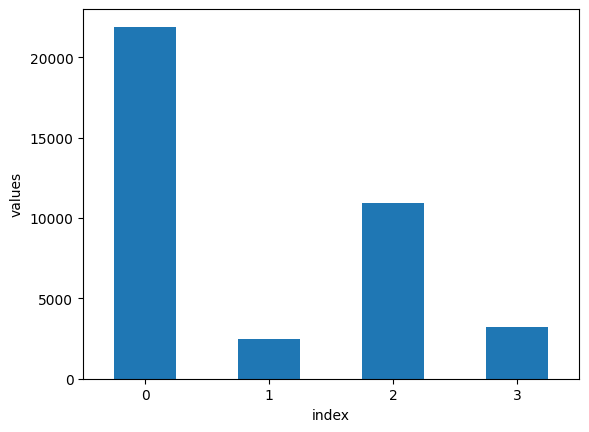

In [22]:
df_train["count"].value_counts().sort_index().plot(kind="bar")
plt.xticks(rotation=0)
plt.xlabel("index")
plt.ylabel("values")
plt.show()